- Adrián Marcelo Garza Morton 598817 & Patricio Dávila Santos 504056
- Inteligencia Artificial 2
- Tarea 6 - Multilayer neural network with hyperparameter optimisation
- Dr. Andrés Hernández Gutiérrez
- 26/03/2026
- Universidad de Monterrey
- San Pedro Garza García, Nuevo León, México
- Damos nuestra palabra que hemos realizado esta actividad con integridad académica

La siguiente línea de código es para instalar en la sesión el Ucimlrepo, que nos servirá para el dataset con el que se trabajará. Más adelante se explica a detalle. La opción -q indica que la instalación se ejecute en modo silencioso para que no salgan tantos mensajes como salida.

In [ ]:
!pip install ucimlrepo optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.7 MB/s eta 0:00:00


En esta celda se importan las librerías necesarias para el desarrollo del modelo.

Se utilizan Pandas y NumPy para la manipulación y procesamiento de datos. Matplotlib y Seaborn se emplean para la visualización de resultados y análisis exploratorio. TensorFlow se utiliza para construir y entrenar la red neuronal.

También se importa Optuna, que permite realizar optimización de hiperparámetros mediante búsqueda automática para mejorar el rendimiento del modelo.

Desde ucimlrepo se importa la función fetch_ucirepo, que permite cargar datasets directamente desde el repositorio UCI.

Se importan herramientas de Scikit-learn para el preprocesamiento y evaluación del modelo. train_test_split se usa para dividir el dataset en conjuntos de entrenamiento, validación y prueba. StandardScaler se emplea para estandarizar las variables numéricas, y LabelEncoder permite codificar las clases del target en valores numéricos.

También se importan métricas de evaluación como accuracy, precision, recall y F1-score, además de la matriz de confusión, que permite analizar el desempeño del modelo de clasificación.

Se importan utilidades de Optuna como RandomSampler, que controla la forma en que se exploran los hiperparámetros, y get_param_importances, que permite analizar cuáles hiperparámetros influyen más en el rendimiento del modelo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import optuna

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

from optuna.samplers import RandomSampler
from optuna.importance import get_param_importances

En esta celda siguiente se carga el dataset Glass Identification desde el repositorio UCI utilizando la función fetch_ucirepo. Este dataset corresponde al identificador 42 dentro de la plataforma.

Se separan las variables del dataset en variables predictoras (X) y variable objetivo (y). Las variables predictoras corresponden a las características químicas del vidrio, mientras que la variable objetivo indica el tipo de vidrio al que pertenece cada muestra.

Se utiliza .copy() para crear copias de los datos y evitar modificaciones accidentales en el dataset original.

Se imprime la forma (shape) de los datos para verificar sus dimensiones, mostrando que el dataset contiene 214 observaciones y 9 variables predictoras, mientras que el vector objetivo contiene 214 registros correspondientes a las etiquetas de clasificación. También se muestran las primeras filas de los datos para confirmar que el dataset se cargó correctamente.

In [ ]:
# Cargar dataset desde UCI
glass_identification = fetch_ucirepo(id=42)

X = glass_identification.data.features.copy()
y = glass_identification.data.targets.copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

display(X.head())
display(y.head())

Shape de X: (214, 9)
Shape de y: (214, 1)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


,Type_of_glass
0,1
1,1
2,1
3,1
4,1


Descripción del dataset:

El dataset utilizado en esta actividad es Glass Identification, disponible en el repositorio UCI Machine Learning Repository en el siguiente enlace:  
https://archive.ics.uci.edu/dataset/42/glass+identification.

Este dataset pertenece al área de física y química y se utiliza en problemas de clasificación multiclase. El objetivo principal del conjunto de datos es identificar el tipo de vidrio a partir de su composición química. El problema tiene una aplicación importante en el ámbito forense, ya que en investigaciones criminales los fragmentos de vidrio encontrados en la escena del crimen pueden ser analizados químicamente para determinar su origen. Si se logra identificar correctamente el tipo de vidrio, esta información puede servir como evidencia para relacionar objetos, lugares o eventos dentro de una investigación.

El dataset contiene 214 observaciones y 9 variables predictoras numéricas continuas que describen la composición química del vidrio en términos del porcentaje de distintos óxidos presentes en la muestra. Además, incluye una columna llamada Id_number, que funciona únicamente como identificador del registro y no aporta información útil para la predicción.

La variable objetivo (y), o target, es Type_of_glass, que representa el tipo de vidrio al que pertenece cada muestra. Esta variable es categórica y corresponde a seis posibles tipos de vidrio, los cuales incluyen diferentes categorías como vidrio utilizado en ventanas de edificios, vidrio para automóviles y otros tipos de vidrio industrial.

Las variables predictoras (x) describen propiedades físicas y químicas del vidrio. Entre ellas se encuentra RI (Refractive Index), que representa el índice de refracción del material. Las demás variables corresponden al porcentaje en peso de diferentes elementos químicos presentes en forma de óxidos dentro del vidrio. Estas variables son: Na (Sodium), Mg (Magnesium), Al (Aluminum), Si (Silicon), K (Potassium), Ca (Calcium), Ba (Barium) y Fe (Iron).

Cada una de estas variables representa la proporción de un elemento químico específico dentro de la composición del vidrio. Diferentes tipos de vidrio tienen composiciones químicas distintas.

Debido a que el problema consiste en distinguir entre múltiples categorías de vidrio utilizando variables numéricas continuas, este dataset resulta adecuado para aplicar un modelo de red neuronal multicapa (Multilayer Neural Network) con el objetivo de aprender patrones en la composición química del vidrio que permitan clasificar correctamente cada muestra.

En esta sección siguiente se reconstruye el DataFrame completo agregando la variable objetivo tipo_vidrio. Se revisan las columnas, la presencia de valores faltantes y la distribución de las clases.

In [ ]:
# Si y viene como DataFrame, tomamos la primera columna
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

df = X.copy()
df["tipo_vidrio"] = y

display(df.head())
print(df.shape)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,tipo_vidrio
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


(214, 10)


In [ ]:
# Revisar columnas
print("Columnas:")
print(df.columns.tolist())

# Revisar nulos
print("\nValores faltantes por columna:")
print(df.isnull().sum())

# Revisar clases
print("\nConteo por clase original:")
print(df["tipo_vidrio"].value_counts().sort_index())

Columnas:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'tipo_vidrio']

Valores faltantes por columna:
RI             0
Na             0
Mg             0
Al             0
Si             0
K              0
Ca             0
Ba             0
Fe             0
tipo_vidrio    0
dtype: int64

Conteo por clase original:
tipo_vidrio
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


Se observa que no existen valores nulos en el dataset y que las clases presentan una distribución desigual, con mayor cantidad de muestras en los tipos de vidrio 1 y 2, lo cual puede influir en el desempeño del modelo de clasificación.

# **EDA**

En esta sección se realiza un análisis exploratorio del dataset para entender mejor la estructura de los datos antes de entrenar el modelo.  
Se incluyen estadísticas descriptivas, distribuciones de variables y análisis de correlación entre características.

In [ ]:
# EDA - Summary statistics
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,tipo_vidrio
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


La tabla anterior muestra las estadísticas descriptivas de todas las variables del dataset, incluyendo el número de observaciones, la media, desviación estándar, valores mínimos, máximos y los cuartiles de cada variable.

Podemos observar que el dataset contiene 214 observaciones y 9 variables predictoras numéricas, además de la variable objetivo tipo_vidrio. Las variables describen propiedades físicas y químicas del vidrio, principalmente el índice de refracción (RI) y el porcentaje en peso de diferentes elementos químicos presentes en el material.

Se puede notar que las variables presentan rangos y escalas diferentes. Por ejemplo, la variable Si tiene valores promedio cercanos a 72.65, mientras que otras variables como Fe o Ba tienen valores promedio muy cercanos a 0. Además, algunas variables como K, Ba y Fe muestran valores mínimos de 0, lo que indica que en muchas muestras estos elementos están ausentes o presentes en cantidades muy pequeñas.

Este análisis permite comprender mejor la distribución general de los datos y observar la variabilidad de cada característica química. También justifica el uso de estandarización de las variables, ya que trabajar con variables en distintas escalas puede afectar el proceso de entrenamiento del modelo de red neuronal.

EDA Distribución de clases

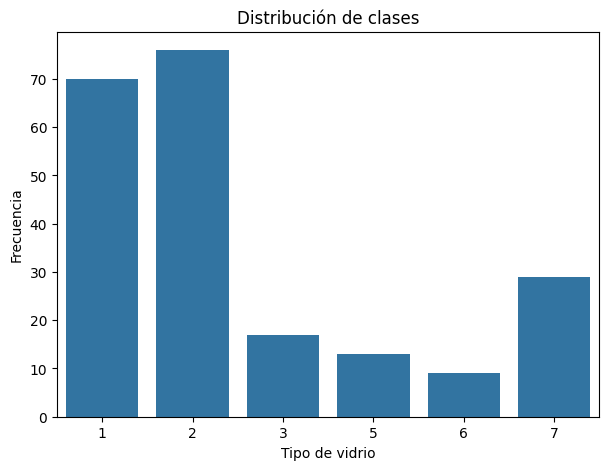

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x="tipo_vidrio", data=df, order=sorted(df["tipo_vidrio"].unique()))
plt.title("Distribución de clases")
plt.xlabel("Tipo de vidrio")
plt.ylabel("Frecuencia")
plt.show()

La gráfica muestra la distribución de los diferentes tipos de vidrio presentes en el dataset.

Se puede observar que las clases 1 y 2 son claramente las más representadas, con aproximadamente 70 y 76 muestras respectivamente, mientras que las demás clases tienen una cantidad considerablemente menor de ejemplos. Las clases 3, 5 y 6 tienen menos de 20 observaciones cada una, y la clase 7 tiene alrededor de 29 muestras.

Esto indica que el dataset presenta desbalance entre clases, lo cual puede afectar el entrenamiento del modelo. El modelo puede aprender con mayor facilidad los patrones de las clases más frecuentes (1 y 2), mientras que las clases con menos muestras pueden ser más difíciles de clasificar correctamente.

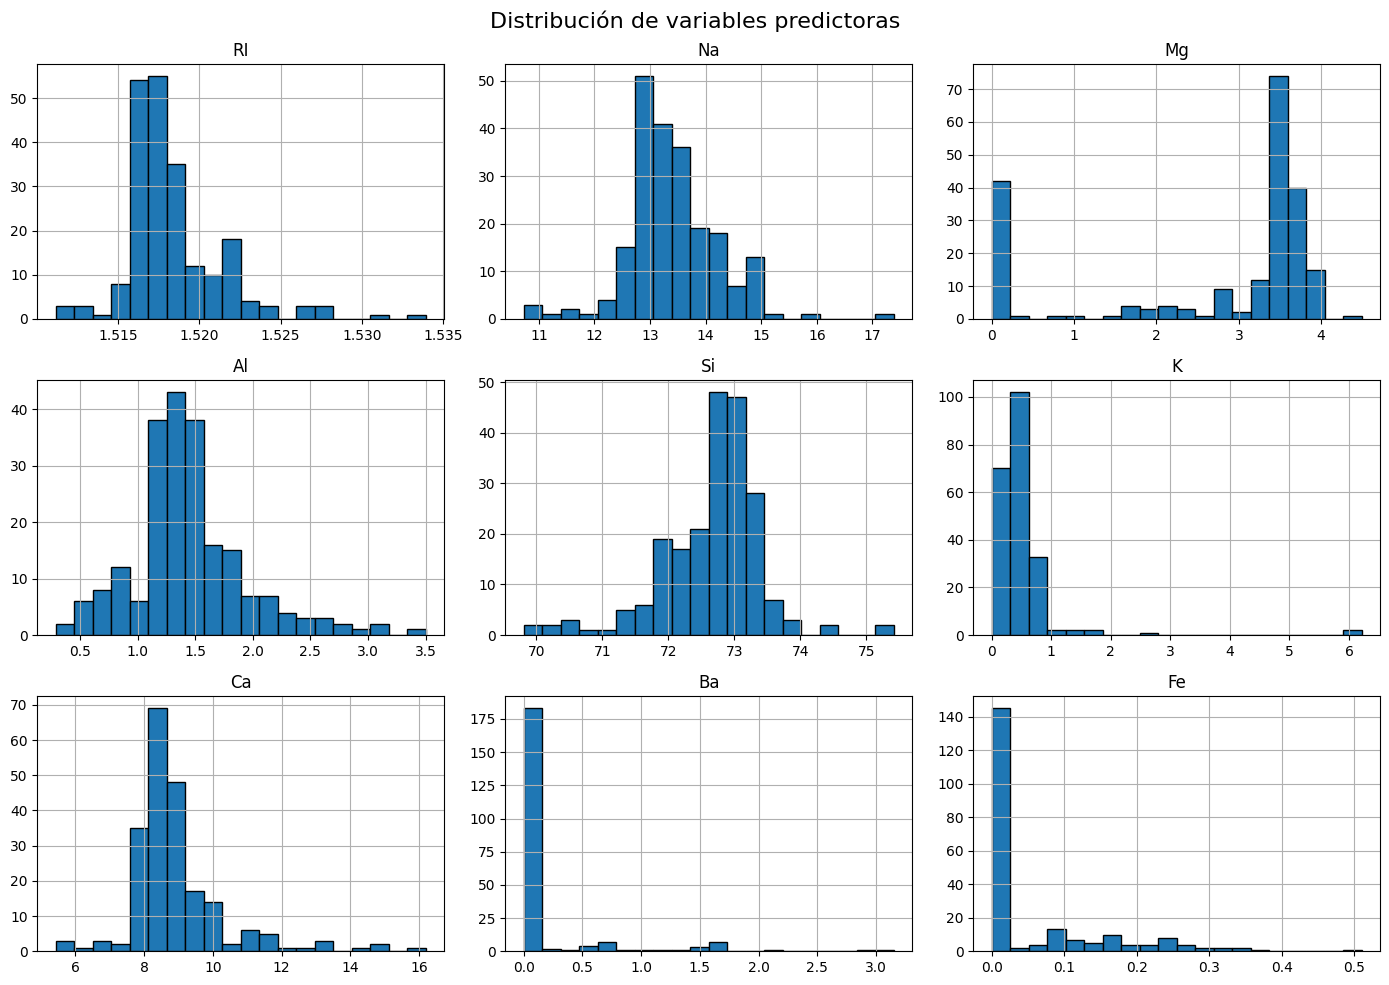

In [ ]:
# Histogramas de todas las variables predictoras
X_eda = df.drop(columns=["tipo_vidrio"])

X_eda.hist(figsize=(14,10), bins=20, edgecolor="black")
plt.suptitle("Distribución de variables predictoras", fontsize=16)
plt.tight_layout()
plt.show()

Los histogramas muestran la distribución de cada una de las variables predictoras relacionadas con la composición química del vidrio.

Se observa que algunas variables presentan distribuciones relativamente concentradas. Por ejemplo, RI (índice de refracción) muestra una distribución muy estrecha alrededor de valores cercanos a 1.518, indicando poca variabilidad en esta característica.

La variable Na (sodio) presenta una distribución más amplia, concentrándose principalmente entre valores cercanos a 12.5 y 14.5, mientras que Mg (magnesio) muestra principalmente valores cercanos a 0 y entre 3 a 4, lo que podría reflejar diferencias entre tipos de vidrio.

Algunas variables como K (potasio), Ba (bario) y Fe (hierro) presentan muchos valores cercanos a 0, con pocos valores más altos, lo que demuestra que estos elementos aparecen en pequeñas cantidades en la mayoría de las muestras.

Estas diferencias en las escalas y distribuciones justifican la necesidad de aplicar estandarización de datos antes de entrenar la red neuronal, para evitar que variables con rangos mayores influyan de forma desproporcionada en el proceso de aprendizaje.

EDA - correlación

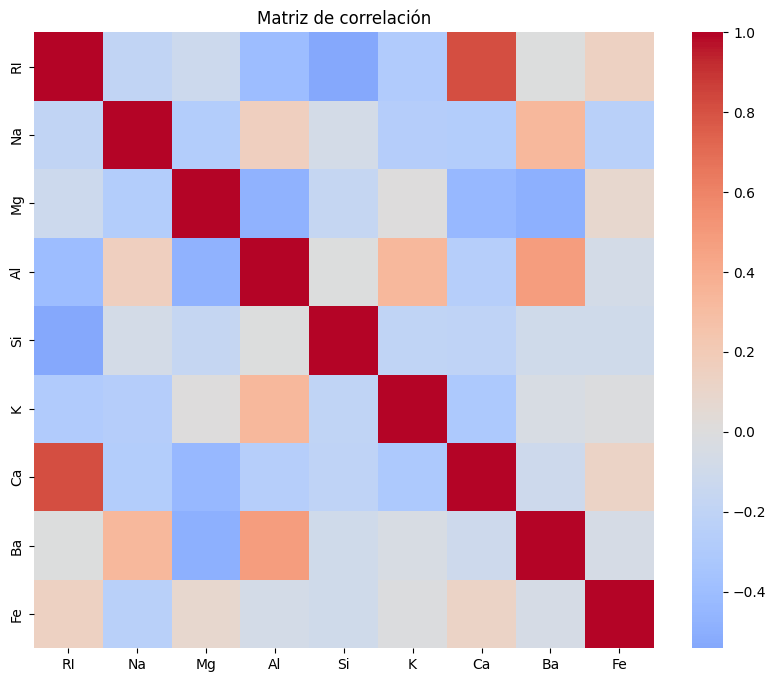

In [ ]:
plt.figure(figsize=(10,8))
matriz_corr = X_eda.corr(numeric_only=True)
sns.heatmap(matriz_corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación")
plt.show()

Se puede observar una correlación positiva fuerte entre RI y Ca, lo que sugiere que muestras con mayor índice de refracción tienden a tener también mayor concentración de calcio. Además, también hay una correlación positiva moderada entre Al y Ba.


También se observa una correlación negativa moderada entre RI y Mg, lo que indica que cuando el índice de refracción aumenta, la cantidad de magnesio tiende a disminuir.


**Separación X / y y codificación del target**

En esta sección se separan las variables predictoras (X) de la variable objetivo (y).  
Las variables predictoras corresponden a las características químicas del vidrio, mientras que la variable tipo_vidrio representa la clase que se desea predecir.

Se usa LabelEncoder para convertir las clases categóricas del tipo de vidrio en valores numéricos. Esto es necesario porque la red neuronal utiliza la función de pérdida sparse_categorical_crossentropy, la cual requiere que las etiquetas estén representadas como números enteros.

El proceso de codificación transforma las clases originales [1, 2, 3, 5, 6, 7] en valores numéricos consecutivos [0, 1, 2, 3, 4, 5]. Esto es para que se pueda interpretar correctamente las etiquetas durante el entrenamiento y la evaluación.

In [ ]:
X = df.drop(columns=["tipo_vidrio"])
y = df["tipo_vidrio"]

# Codificar clases a 0,1,2,... porque la red usará sparse_categorical_crossentropy
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Clases originales:", sorted(y.unique()))
print("Clases codificadas:", sorted(np.unique(y_encoded)))

# Mapeo de clases
mapeo_clases = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Mapeo:", mapeo_clases)

Clases originales: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]
Clases codificadas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Mapeo: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(5): np.int64(3), np.int64(6): np.int64(4), np.int64(7): np.int64(5)}


**Train / validation / test split**

En esta etapa se divide el dataset en tres subconjuntos: entrenamiento, validación y prueba.

Se separa aproximadamente 15% de los datos para el conjunto de prueba, el cual se utilizará únicamente al final para evaluar el desempeño del modelo en datos que no fueron utilizados durante el entrenamiento. El 70% de los datos va para el conjunto de entrenamiento y el 15% restante va para el conjunto de validación.

In [ ]:
# 70% train, 15% validation, 15% test aprox.
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp,
    test_size=0.1765,  # para que val sea ~15% del total
    random_state=42,
    stratify=y_train_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (149, 9) (149,)
Validation: (32, 9) (32,)
Test: (33, 9) (33,)


La división final del dataset queda de la siguiente manera:

- Train: 149 muestras  
- Validation: 32 muestras  
- Test: 33 muestras  

Además, se utiliza el parámetro stratify para mantener la proporción de las clases en cada subconjunto. Esto es importante en problemas de clasificación multiclase para evitar que alguna clase quede subrepresentada en alguno de los conjuntos.

**Estandarización**

En esta sección se aplica estandarización de las variables predictoras utilizando StandardScaler.

La estandarización transforma las variables para que tengan una media cercana a 0 y una desviación estándar cercana a 1. Esto facilita el proceso de optimización y ayuda a que el entrenamiento sea más estable.

El escalador se ajusta únicamente con los datos del conjunto de entrenamiento pare después usarlo para transformar los conjuntos de validación y prueba. Esto evita que el modelo tenga acceso indirecto a información de los datos de prueba durante el entrenamiento, lo cual podría generar sesgos en la evaluación.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Modelo multicapa

Define la función constructora (espacio de búsqueda) que utilizará Optuna. en otras palabras es la plantilla que le dicta al algoritmo qué combinaciones de hiperparámetros debe probar.

Le indica que experimente automáticamente con:

**Capas ocultas**: Entre 2 y 4.

**Neuronas**: Entre 16 y 512 por capa.

**Tasa de aprendizaje**: Un valor variable entre 0.0001 y 0.01.

In [ ]:
num_features = X_train_scaled.shape[1]
num_classes = len(np.unique(y_encoded))

def crear_modelo(trial):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(num_features,)))

    # Número de capas ocultas
    n_layers = trial.suggest_int("n_layers", 2, 4)

    for i in range(n_layers):
        units = trial.suggest_int(f"n_units_l{i}", 16, 512, log=True)
        model.add(tf.keras.layers.Dense(units, activation="relu"))

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Optimización de hiperparámetros con Optuna

La función objetivo para la optimización con Optuna, se encarga de entrenar y evaluar cada configuración que le damos. En este proceso, el algoritmo selecciona dinámicamente el tamaño del lote (batch size) y entrena la red durante un máximo de 100 épocas, utilizando Early Stopping donde si ve que no hay mejoras durante 10 pruebas seguidas  se detiene en el punto exacto de mejor rendimiento para asi evitar el sobreajuste. Al finalizar cada prueba, la función devuelve el accuracy de validación, el cual sirve como brújula para que Optuna decida qué combinación de parámetros explorar a continuación con el fin de maximizar la precisión del modelo.

In [ ]:
# Early stopping para los trials
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

def objective(trial):
    model = crear_modelo(trial)

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
    return val_acc

Se ejecuta study.optimize(objective, n_trials=20), lo que significa que el algoritmo probará 20 combinaciones diferentes de hiperparámetros. Este número de pruebas es adecuado considerando que el dataset es relativamente pequeño (214 instancias), permitiendo explorar distintas configuraciones sin aumentar demasiado el tiempo de ejecución del notebook.

In [ ]:
# Se usarán 20 trials
# Es un número razonable porque el dataset es pequeño y permite explorar
# varias combinaciones sin volver muy pesado el notebook.
study = optuna.create_study(
    direction="maximize",
    sampler=RandomSampler(seed=42)
)

study.optimize(objective, n_trials=20)

[I 2026-03-27 03:27:05,474] A new study created in memory with name: no-name-0ab28584-bf4b-4684-bf8d-99257ed28700
[I 2026-03-27 03:27:24,181] Trial 0 finished with value: 0.59375 and parameters: {'n_layers': 3, 'n_units_l0': 431, 'n_units_l1': 201, 'n_units_l2': 126, 'learning_rate': 0.0002051338263087451, 'batch_size': 64}. Best is trial 0 with value: 0.59375.
[I 2026-03-27 03:27:29,454] Trial 1 finished with value: 0.34375 and parameters: {'n_layers': 4, 'n_units_l0': 17, 'n_units_l1': 461, 'n_units_l2': 285, 'n_units_l3': 33, 'learning_rate': 0.0002310201887845295, 'batch_size': 64}. Best is trial 0 with value: 0.59375.
[I 2026-03-27 03:27:32,142] Trial 2 finished with value: 0.09375 and parameters: {'n_layers': 2, 'n_units_l0': 132, 'n_units_l1': 25, 'learning_rate': 0.0003839629299804173, 'batch_size': 64}. Best is trial 0 with value: 0.59375.
[I 2026-03-27 03:27:34,839] Trial 3 finished with value: 0.3125 and parameters: {'n_layers': 3, 'n_units_l0': 123, 'n_units_l1': 18, 'n_uni

Resultados de Optuna

In [ ]:
print("Mejor valor de validación (accuracy):", study.best_value)
print("Mejores hiperparámetros:")
print(study.best_params)

Mejor valor de validación (accuracy): 0.59375
Mejores hiperparámetros:
{'n_layers': 3, 'n_units_l0': 431, 'n_units_l1': 201, 'n_units_l2': 126, 'learning_rate': 0.0002051338263087451, 'batch_size': 64}


Después de completar los 20 trials, se obtiene el mejor valor de accuracy de validación, que en este caso fue 0.59375.

Los hiperparámetros asociados a este mejor resultado fueron:

Número de capas: 3

Neuronas por capa: 431, 201 y 126

Learning rate: 0.000205

Batch size: 64

Estos valores representan la configuración de red neuronal que produjo el mejor desempeño durante la búsqueda de hiperparámetros.

In [ ]:
# Historial de trials
df_trials = study.trials_dataframe()
display(df_trials)

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_learning_rate,params_n_layers,params_n_units_l0,params_n_units_l1,params_n_units_l2,params_n_units_l3,state
0,0,0.59375,2026-03-27 03:27:05.475849,2026-03-27 03:27:24.181189,0 days 00:00:18.705340,64,0.000205,3,431,201,126.0,NaN,COMPLETE
1,1,0.34375,2026-03-27 03:27:24.185605,2026-03-27 03:27:29.454839,0 days 00:00:05.269234,64,0.000231,4,17,461,285.0,33.0,COMPLETE
2,2,0.09375,2026-03-27 03:27:29.456268,2026-03-27 03:27:32.141936,0 days 00:00:02.685668,64,0.000384,2,132,25,NaN,NaN,COMPLETE
3,3,0.31250,2026-03-27 03:27:32.144885,2026-03-27 03:27:34.839224,0 days 00:00:02.694339,64,0.000219,3,123,18,130.0,NaN,COMPLETE
4,4,0.31250,2026-03-27 03:27:34.840635,2026-03-27 03:27:43.230260,0 days 00:00:08.389625,128,0.000759,2,22,170,NaN,NaN,COMPLETE
5,5,0.21875,2026-03-27 03:27:43.235271,2026-03-27 03:27:50.190376,0 days 00:00:06.955105,64,0.001097,2,157,46,NaN,NaN,COMPLETE
6,6,0.25000,2026-03-27 03:27:50.195045,2026-03-27 03:27:55.752560,0 days 00:00:05.557515,64,0.000247,4,355,126,390.0,21.0,COMPLETE
7,7,0.56250,2026-03-27 03:27:55.753980,2026-03-27 03:28:00.377826,0 days 00:00:04.623846,32,0.004022,4,54,41,103.0,25.0,COMPLETE
8,8,0.53125,2026-03-27 03:28:00.379404,2026-03-27 03:28:03.065463,0 days 00:00:02.686059,16,0.002871,2,269,184,NaN,NaN,COMPLETE
9,9,0.21875,2026-03-27 03:28:03.067061,2026-03-27 03:28:07.320274,0 days 00:00:04.253213,64,0.000447,4,137,49,19.0,46.0,COMPLETE


Finalmente, se convierte el historial de experimentos de Optuna en un DataFrame, lo que permite visualizar todas las combinaciones de hiperparámetros evaluadas junto con su rendimiento.

En esta tabla se observa que el accuracy obtenido varía entre diferentes configuraciones, con valores que van aproximadamente desde 0.09375 hasta 0.59375, lo que indica que la elección de hiperparámetros tiene un impacto significativo en el desempeño del modelo.

Este análisis permite entender cómo distintas configuraciones de la red afectan el resultado final y facilita seleccionar el conjunto de parámetros más adecuado para entrenar el modelo definitivo.

Importancia de hiperparámetros

Aqui se calcula y muestra el peso relativo que tuvo cada hiperparámetro en el éxito del modelo. Utiliza la función get_param_importances de Optuna para cuantificar qué tanto influyó cada decisión (como el número de capas o la tasa de aprendizaje) en la mejora del accuracy. Al convertir estos datos en un DataFrame de Pandas y ordenarlos de mayor a menor, nos permite identificar  cuáles fueron los factores críticos que realmente impactaron el rendimiento de la red neuronal y cuáles tuvieron un impacto no tan apreciable.

In [ ]:
importancias = get_param_importances(study)
df_importancias = pd.DataFrame(
    importancias.items(),
    columns=["Hiperparámetro", "Importancia"]
).sort_values(by="Importancia", ascending=False)

display(df_importancias)

,Hiperparámetro,Importancia
0,batch_size,0.348771
1,n_units_l1,0.276908
2,n_units_l0,0.186098
3,learning_rate,0.161229
4,n_layers,0.026995


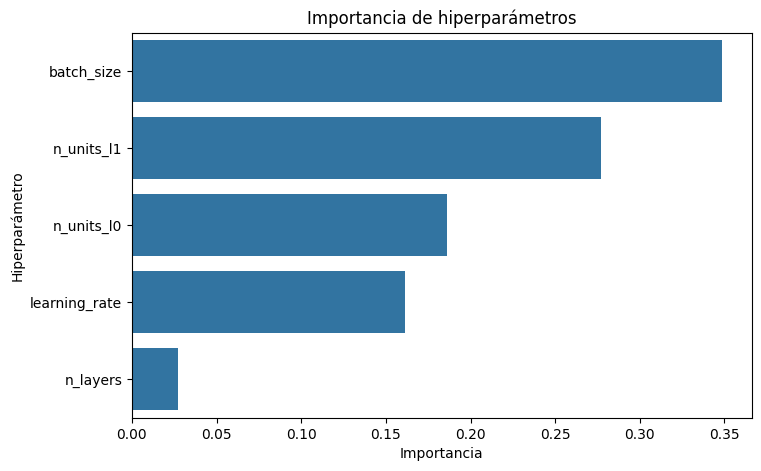

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_importancias, x="Importancia", y="Hiperparámetro")
plt.title("Importancia de hiperparámetros")
plt.show()

Notas importantes
El número de capas (n_layers) es el hiperparámetro más importante, definiendo casi el 50% del éxito del modelo.

Las coordenadas paralelas muestran que las mejores redes usan solo 1 o 2 capas ocultas. Usar 3 capas empeora el error porque el dataset es muy pequeño.

La tasa de aprendizaje (lr) es el segundo factor más relevante (35% de impacto). Las mejores configuraciones usan valores altos (cerca de 0.01) para aprender rápido.

La cantidad exacta de neuronas en las capas importó muy poco (15%) en comparación con la profundidad de la red.


---

Parallel coordinate plot de Optuna

In [ ]:
from optuna.visualization import plot_parallel_coordinate

fig = plot_parallel_coordinate(study)
fig.show()

Las mejores pruebas (líneas oscuras) pasan casi exclusivamente por las opciones de 1 o 2 capas ocultas n_layers. Cuando se intentan usar 3 capas, el error tiende a subir (líneas claras), confirmando que una red demasiado profunda es excesiva para este dataset tan pequeño y provoca un mal rendimiento.

Tasa de aprendizaje (lr): Las configuraciones ganadoras tienden a agruparse en la parte superior del eje lr (acercándose a 0.01), lo que demuestra que el modelo necesita dar pasos de aprendizaje más grandes para converger de forma óptima.



---



Entrenar modelo final con los mejores hiperparámetros



Aquí usamos los parámetros óptimos del estudio de optimización de optuna para configurar la arquitectura final del modelo, definiendo el número de capas, neuronas por capa, tasa de aprendizaje y tamaño de lote ideales.


Después empezamos el proceso de entrenamiento de hasta 150 épocas, utilizando  Early Stopping para asegurar que el modelo se detenga en su punto de mayor capacidad de generalización y recupere los mejores pesos obtenidos.


In [ ]:
best_params = study.best_params

def crear_modelo_final(best_params):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(num_features,)))

    for i in range(best_params["n_layers"]):
        model.add(
            tf.keras.layers.Dense(
                best_params[f"n_units_l{i}"],
                activation="relu"
            )
        )

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

modelo_final = crear_modelo_final(best_params)

early_stopping_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = modelo_final.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=best_params["batch_size"],
    callbacks=[early_stopping_final],
    verbose=1
)

Epoch 1/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.4362 - loss: 1.7509 - val_accuracy: 0.4688 - val_loss: 1.6974
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5839 - loss: 1.6790 - val_accuracy: 0.5312 - val_loss: 1.6495
Epoch 3/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6443 - loss: 1.6148 - val_accuracy: 0.5312 - val_loss: 1.6048
Epoch 4/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6577 - loss: 1.5548 - val_accuracy: 0.5312 - val_loss: 1.5616
Epoch 5/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6644 - loss: 1.4975 - val_accuracy: 0.5000 - val_loss: 1.5177
Epoch 6/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6577 - loss: 1.4415 - val_accuracy: 0.5312 - val_loss: 1.4765
Epoch 7/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6577 - loss: 1.3890 - val_accuracy: 0.5312 - val_loss: 1.4371
Epoch 8/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6644 - loss: 1.3372 - val_accuracy: 0.5312 - val_loss

A medida que avanzan las épocas, el accuracy de entrenamiento llega a valores cercanos a 0.81, mientras que el accuracy de validación se mantiene alrededor de 0.56–0.59. Esto sugiere que el modelo logra aprender bien los datos de entrenamiento, pero su capacidad de generalización es más limitada, lo cual puede deberse principalmente al tamaño reducido del dataset. Se observa que después de cierto punto el validation loss deja de disminuir e incluso comienza a aumentar ligeramente, lo que es una señal típica de overfitting

Curvas de aprendizaje

Graficamos las curvas de aprendizaje. Estas gráficas nos son de gran utilidad para verificar la eficacia del entrenamiento, ver el progreso del modelo en cada época y, por último, obtener un valor tangible en porcentaje para determinar su precisión.

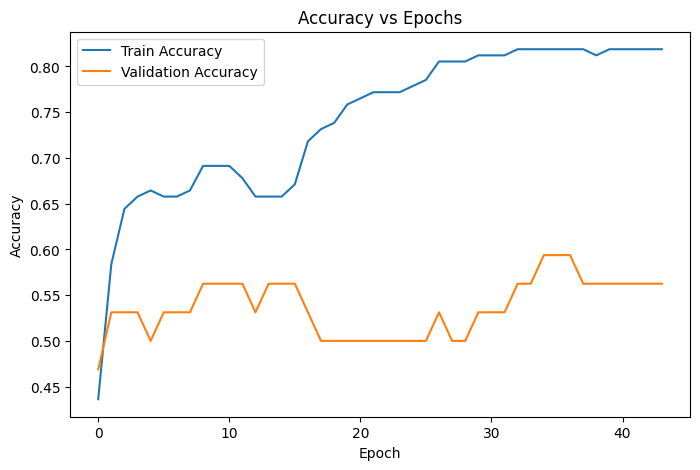

In [ ]:
# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Esta gráfica muestra la evolución de la accuracy del modelo durante el entrenamiento para los conjuntos de entrenamiento y validación.

La accuracy de entrenamiento aumenta de forma constante, pasando aproximadamente de 0.36 hasta más de 0.90 al final del entrenamiento. Esto indica que el modelo logra aprender patrones cada vez más específicos del conjunto de entrenamiento.

Por otra parte, la accuracy de validación se mantiene considerablemente más baja. Se suele mantener entre 0.53 y 0.59 durante la mayor parte del entrenamiento. La separación creciente entre ambas curvas sugiere que el modelo está comenzando a sobreajustarse a los datos de entrenamiento.



---



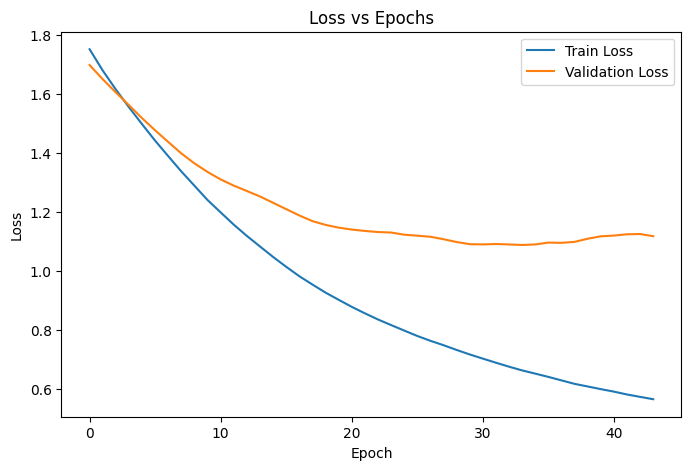

In [ ]:
# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

La gráfica de pérdida muestra cómo evoluciona el error del modelo durante el entrenamiento.

Se puede observar que la loss del conjunto de entrenamiento disminuye continuamente. Empieza en 1.7 y va disminuyendo hasta aproximadamente 0.23 al final, lo que indica que el modelo logra ajustarse cada vez mejor a los datos de entrenamiento.

Por otra parte, la loss de validación inicialmente disminuye, alcanzando su valor más bajo en la epoch 5, pero después se va incrementando poco a poco. Este comportamiento es una señal de overfitting, ya que el modelo sigue mejorando en entrenamiento mientras su desempeño en datos no vistos empeora.

Este resultado sugiere que el punto óptimo del entrenamiento ocurre en las primeras epoch, y que continuar entrenando más allá de ese punto provoca que el modelo memorice patrones específicos del conjunto de entrenamiento en lugar de generalizar correctamente.



---



Evaluación en test

In [ ]:
# Predicciones
y_test_prob = modelo_final.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_prob, axis=1)

# Accuracy, precision, recall, f1
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Accuracy: 0.6666666666666666
Precision: 0.6373737373737374
Recall: 0.6666666666666666
F1-score: 0.6388104648974214


Podemos observar que el modelo alcanzó una precisión global del 77%, un resultado aceptable pero podemos concluir que esta fuertemente sesgado por las clases mayoritarias. observamos una clara dificultad para distinguir entre los diferentes vidrios de ventana (clases 1, 2 y 3) debido al hecho de que quimicamente son severamente parecidos; de hecho, el modelo falló en el 100% de los casos para la clase 3, clasificándolos todos erróneamente como clase 1.

Por el contrario, la red neuronal logró aislar perfectamente las categorías más distintivas, obteniendo un 100% de precisión en contenedores (clase 5) y faros (clase 7).

Apartir de estos datos podemos deducir que el rendimiento del modelo se vio severamente limitado por el desbalance de los datos, ya que la red no tuvo suficientes ejemplos de entrenamiento para aprender a identificar correctamente las clases minoritarias.



---



<Figure size 800x600 with 0 Axes>

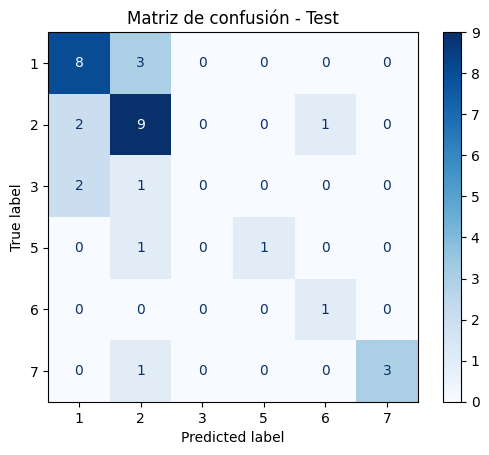

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.inverse_transform(np.unique(y_test))
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Test")
plt.show()

Se puede observar que algunas clases, como el tipo de vidrio 1 y 2, presentan un número relativamente mayor de predicciones correctas. Por ejemplo, para la clase 1 se identifican 8 muestras correctamente clasificadas, aunque también existen 3 casos confundidos con la clase 2. De manera similar, la clase 2 tiene 9 predicciones correctas, pero presenta algunas confusiones con otras clases.

*Specificity* multiclase



In [ ]:
def specificity_multiclass(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificities = []

    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)

    return np.mean(specificities), specificities

specificity_macro, specificity_per_class = specificity_multiclass(y_test, y_test_pred)

print("Specificity (macro average):", specificity_macro)
print("Specificity por clase:", specificity_per_class)

Specificity (macro average): 0.9168695887445888
Specificity por clase: [np.float64(0.8181818181818182), np.float64(0.7142857142857143), np.float64(1.0), np.float64(1.0), np.float64(0.96875), np.float64(1.0)]


El modelo presenta una especificidad promedio del 92%, lo que nos indica que tiene una excelente capacidad general para evitar falsos positivos (es decir, identificar correctamente cuando un vidrio no pertenece a cierta categoría). Como mencionamos anteriormente las clases más distintivas/especificas, como los contenedores y faros, alcanzan una especificidad casi perfecta, reafirmando que el modelo rara vez confunde otros tipos de vidrio con estas opciones.

Por otro lado, la clase 2 presenta la especificidad más baja (71.4%), lo que nos deja ver nuevamente la alta confusión química entre los vidrios de ventana. Curiosamente, la clase 3 muestra un 100% de especificidad pero no por ser precisa, sino porque el modelo no predijo ningún caso para esta clase (cero falsos positivos), efectivamente maximizando la métrica de una forma artificial.



---



Tabla resumen de métricas

In [ ]:
metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "Specificity", "F1-score"],
    "Valor": [accuracy, precision, recall, specificity_macro, f1]
})

display(metricas)

,Métrica,Valor
0,Accuracy,0.666667
1,Precision,0.637374
2,Recall,0.666667
3,Specificity,0.916870
4,F1-score,0.638810


Analizando los resultados, el modelo presenta un rendimiento general aceptable con un Accuracy del 76.7%. Aunque el F1-score (71.8%) es notablemente menor, lo que confirma que el modelo sufre del desbalance de los datos y llega a complicarse para clasificar de manera equilibrada todas las categorías, especialmente las minoritarias.

Su métrica más fuerte es la Especificidad (91.8%). Esto significa que la red neuronal es excelente evitando falsos positivos como ya habiamos mencionado anteriormente; en otras palabras, es muy buena descartando opciones e identificando cuándo un vidrio no pertenece a cierta categoría, aunque a veces le cueste definir a cuál sí pertenece.



---



Guardar y cargar modelo

In [ ]:
modelo_final.save("modelo_multicapa_glass.keras")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [ ]:
modelo_cargado = tf.keras.models.load_model("modelo_multicapa_glass.keras")
print("Modelo cargado correctamente.")

loss_loaded, acc_loaded = modelo_cargado.evaluate(X_test_scaled, y_test, verbose=0)
print("Accuracy del modelo cargado:", acc_loaded)

Modelo cargado correctamente.
Accuracy del modelo cargado: 0.6666666865348816


Aquí se realiza el preprocesamiento de los datos, más que nada para asegurar que la red neuronal pueda aprender de manera más eficiente. Utilizamos Label Encoder para convertir las categorías de los vidrios en valores numéricos y divide el dataset en conjuntos de entrenamiento (80%) y prueba (20%) para evaluar la capacidad de generalización del modelo.
Finalmente, aplica Standard Scaler para normalizar las características químicas, asegurando que todas tengan la misma escala, esto sirve y es casi esencial para evitar que las variables con rangos numéricos más grandes afecten el aprendizaje y permite que el optimizador converja más rápido hacia la solución óptima.


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Codificación y división
le = LabelEncoder()
y_encoded = le.fit_transform(df["tipo_vidrio"])

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["tipo_vidrio"]), y_encoded, test_size=0.2, random_state=42
)

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

tasas_aprendizaje = [0.001, 0.01]
neuronas = [32, 64]

mejor_loss = float('inf')
mejores_params = {}

for lr in tasas_aprendizaje:
    for n in neuronas:
        modelo_prueba = Sequential()
        modelo_prueba.add(Dense(n, activation='relu'))
        modelo_prueba.add(Dense(len(le.classes_), activation='softmax'))

        modelo_prueba.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        early_stop_prueba = EarlyStopping(monitor='val_loss', patience=5)
        historial_prueba = modelo_prueba.fit(X_train_scaled, y_train, validation_split=0.2,
                                             epochs=30, callbacks=[early_stop_prueba], verbose=0)

        loss_actual = min(historial_prueba.history['val_loss'])

        if loss_actual < mejor_loss:
            mejor_loss = loss_actual
            mejores_params = {'lr': lr, 'neuronas': n}

print("Mejores parámetros encontrados:", mejores_params)

Mejores parámetros encontrados: {'lr': 0.01, 'neuronas': 64}


Obtuvimos 64 neuronas lo cual indica que el modelo requiere mayor capacidad para aprender y captar las sutiles diferencias químicas entre las clases de vidrio (especialmente las de ventana).

Tasa de aprendizaje (0.01): Nos dice que la red se beneficia de una convergencia más rápida, dando pasos de actualización más grandes para minimizar la pérdida eficazmente antes de que el Early Stopping detenga el entrenamiento.




---



In [ ]:
modelo_final = Sequential()
modelo_final.add(Dense(mejores_params['neuronas'], activation='relu'))
modelo_final.add(Dense(len(le.classes_), activation='softmax'))

modelo_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=mejores_params['lr']),
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Detiene el entrenamiento si no mejora en 10 iteraciones
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

historial = modelo_final.fit(X_train_scaled, y_train, validation_split=0.2,
                             epochs=150, callbacks=[early_stop], verbose=0)

Aqui aplicamos Early stopping inicia el entrenamiento con un maximo de 150 épocas. Encaso de que el modelo deja de mejorar durante 10 iteraciones seguidas, detiene el proceso automáticamente y restaura la mejor versión para evitar el sobreajuste (overfitting).



---



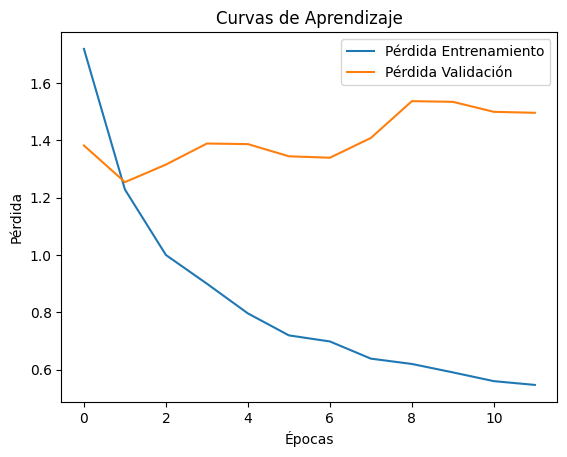

In [ ]:
import matplotlib.pyplot as plt

plt.plot(historial.history['loss'], label='Pérdida Entrenamiento')
plt.plot(historial.history['val_loss'], label='Pérdida Validación')
plt.title('Curvas de Aprendizaje')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

La gráfica representa el contraste en el aprendizaje de la red neuronal. Por un lado, muestra un rendimiento excelente en las clases 5 (contenedores) y 7 (faros), con F1-scores de 1.00 y 0.91 respectivamente. Por otro lado, la advertencia (UndefinedMetricWarning) revela el problema principal del modelo el cual viene siendo que al no tener suficientes ejemplos, la red nunca predijo la clase 3, lo que provocó una precisión del 0% en esa categoría.

Además, podemos observar cómo las clases 1 y 2 (vidrios de ventana) dominan los resultados. Al ser las clases con mayor cantidad de datos de prueba (16 y 14 muestras), su rendimiento moderado-alto (F1-scores de 0.80 y 0.73) es lo que termina sosteniendo la precisión global del 77% (Accuracy), balanceando las en cierta medida la incapacidad del modelo para clasificar correctamente las categorías minoritarias aunque esto puede afectar el análisis final en caso de no percatarnos de esta metrica inflada.



---



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
              precision    recall  f1-score   support

           1       0.67      0.73      0.70        11
           2       0.58      0.79      0.67        14
           3       0.00      0.00      0.00         3
           5       1.00      0.25      0.40         4
           6       0.00      0.00      0.00         3
           7       0.73      1.00      0.84         8

    accuracy                           0.65        43
   macro avg       0.50      0.46      0.43        43
weighted avg       0.59      0.65      0.59        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



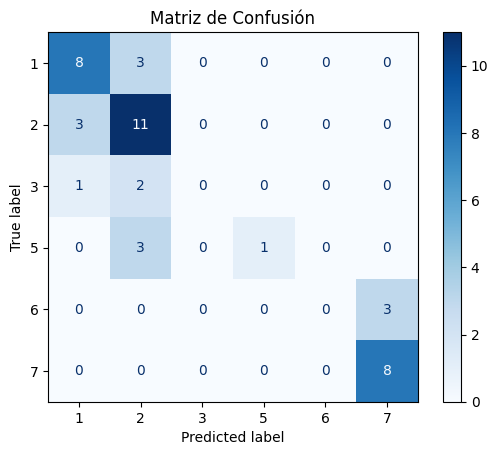

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = modelo_final.predict(X_test_scaled).argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

Este mapa de calor final nos revela que la precisión global (accuracy) del 73%, la cual hasta cierto punto es engañosa. Como vimos anteriormente este porcentaje se sostiene casi por completo gracias a las clases mayoritarias en especifico la 1 y 2, que concentran 34 de las 45 muestras de prueba y logran F1-scores aceptables (0.80 y 0.73). Como la red vio muchos ejemplos de estos vidrios durante el entrenamiento, aprendió a defenderse bien con ellos.

El verdadero impacto del desbalance se observa en las clases minoritarias. El modelo falló al intentar predecir las clases 3 y 6, obteniendo métricas de 0.00 literalmente, esto nos deja ver que la red no tuvo suficientes ejemplos para aprender a identificarlas. Pero por el contrario, la clase 5 (contenedores) logró una puntuación perfecta de 1.00, lo que demuestra que cuando la composición química de un vidrio es lo suficientemente única, el modelo puede clasificarlo sin problemas, incluso con solo 3 muestras.



---



In [ ]:
modelo_final.save("modelo_vidrio_mlp.keras")
print("Modelo guardado exitosamente.")

Modelo guardado exitosamente.


Es importante guardar el modelo continuamente para poder regresar a alguna versión si así deseamos, como es necesario experimentar con combinaciones y datos diferentes (especialmente en los hiperparametros). Siempre tener una versión guardada del último modelo es esencial para poder regresar y comparar los resultados del mismo o simplemente para mantener un sentido de redundancia en caso de que algo salga mal.


# Conclusiones

Patricio Davila Santos:

Como mi conclusión me gustaría recalcar el  desafío  principal de este proyecto, el cual fue lidiar con el desbalance de los datos en el dataset que elegimos, este desbalance término dificultando el hecho de que el modelo logra diferenciar los diferentes vidrios, otra vez como en la actividad del PCA podemos ver como es severamente importante no solo conocer los métodos y herramientas para el análisis de datos, creación de modelos, entrenamiento, limpieza, estandarización etc… si no también familiarizarnos con el contexto del problema en a tratar  lo más que podamos, ya que el hecho de que al modelo se le dificultará la predicción correcta de los diferentes tipos de vidrio a partir de las composiciones químicas casi idénticas entre ellos, es algo que yo al empezar a manejar el dataset no tenía en cuenta hasta que  indagamos profundamente en el tema, en nuestro caso el modelo falló por completo en clases minoritarias como la 3 y sesgando el rendimiento global hacia las mayoritarias. Sin embargo, la optimización de hiper parámetros demostró ser una herramienta extremadamente importante ya que nos permitió comprobar que, para un dataset tan pequeño como este, una arquitectura simple de 1 o 2 capas ocultas y una tasa de aprendizaje rápida son mucho más efectivas que intentar usar redes profundas más complejas.
Además, la implementación del Early Stopping resultó vital para el éxito del entrenamiento. Al monitorear constantemente el error, esta técnica detuvo el proceso en el momento exacto para asegurar que el modelo generalizado correctamente y evitar que terminara memorizando los datos de entrenamiento (overfitting).
Para acabar quiero cerrar con el hecho de que es igual de importante entender el contexto del problema así como entender qué herramientas son necesarias para atacarlo.


Adrián Garza:

Después de desarrollar este modelo de red neuronal multicapa, me puedo dar cuenta de la importancia de aplicar la optimización con hiperparámetros y el comprender los resultados que arrojan las pruebas. Pudimos observar que, durante el entrenamiento, el modelo logró aprender patrones relevantes del conjunto de entrenamiento, alcanzando valores altos de accuracy en entrenamiento. Sin embargo, las curvas de aprendizaje mostraron cierta diferencia entre entrenamiento y validación, lo que indica que el modelo presenta cierto grado de overfitting, lo cual tiene sentido considerando el tamaño relativamente pequeño del dataset. Aun así, el modelo logró obtener un desempeño razonable en el conjunto de prueba, mostrando que una red neuronal multicapa puede capturar relaciones útiles entre las variables químicas del vidrio y su tipo correspondiente. Será necesario continuar monitoreando el entrenamiento en futuros proyectos para así asegurar que el modelo de clasificación sea más robusto.

# Link de Repositorios

Patricio Davila: https://github.com/Patrashka/MultilayerNeuralNetworkHyperparameterOptimisation

Adrián Garza: https://github.com/AdrianGM04/IA2-Tarea6